### ============================================================
# Análise de Performance e Simulação Financeira: Clínica de Psicologia BH
### ============================================================

## Importações de dados e bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df_pacientes = pd.read_csv("pacientes_anonimizado.csv")
df_gastos = pd.read_csv("gastos_anonimizado.csv")
df_atendimentos = pd.read_csv("atendimentos_anonimizado.csv")

## Análise Inicial

In [3]:
print("PACIENTES")
display(df_pacientes.head())
print(df_pacientes.info())

print("\nGASTOS")
display(df_gastos.head())
print(df_gastos.info())

print("\nATENDIMENTOS")
display(df_atendimentos.head())
print(df_atendimentos.info())

PACIENTES


,nome,gênero,data_de_nascimento,idade,profissão,presencial_ou_online,psicologa_responsável,tipo_de_atendimento,valor_por_sessão,como_conheceu_a_clínica
0,Paciente 1,Feminino,2002-08-28,23.00,Estudante de Direito,Presencial,Psicologa 3,Semanal,"R$ 100,00",Instagram
1,Paciente 2,Feminino,2005-05-16,20.00,Concursada,Presencial,Psicologa 3,Semanal,"R$ 150,00",Instagram
2,Paciente 3,Feminino,1984-11-19,41.00,Administrativo,Presencial,Psicologa 3,Semanal,"R$ 70,00",Anúncio Prédio
3,Paciente 4,Feminino,1981-12-10,44.00,Estudante,Presencial,Psicologa 3,Semanal,"R$ 100,00",Indicação Médico
4,Paciente 5,Feminino,1974-11-15,51.00,Desempregada,Online,Psicologa 3,Semanal,"R$ 137,50",Google


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   nome                     76 non-null     object 
 1   gênero                   76 non-null     object 
 2   data_de_nascimento       70 non-null     object 
 3   idade                    71 non-null     float64
 4   profissão                69 non-null     object 
 5   presencial_ou_online     76 non-null     object 
 6   psicologa_responsável    67 non-null     object 
 7   tipo_de_atendimento      76 non-null     object 
 8   valor_por_sessão         76 non-null     object 
 9   como_conheceu_a_clínica  76 non-null     object 
dtypes: float64(1), object(9)
memory usage: 6.1+ KB
None

GASTOS


,Tipo,Valor,Mês
0,Aluguel,"R$ 2.823,89",Dezembro
1,Condominio,"R$ 518,38",Dezembro
2,Condominio,"R$ 509,22",Dezembro
3,Contabilidade,"R$ 148,00",Dezembro
4,Luz,"R$ 64,34",Dezembro


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tipo    61 non-null     object
 1   Valor   61 non-null     object
 2   Mês     61 non-null     object
dtypes: object(3)
memory usage: 1.6+ KB
None

ATENDIMENTOS


,data,nome,psicologa,tipo_atendimento,valor_sessao,status,motivo,obs,mes
0,02/12/2025,Paciente 26,Psicologa 1,Individual,"R$ 100,00",Realizada,-,-,Dezembro
1,02/12/2025,Paciente 34,Psicologa 1,Individual,"R$ 100,00",Realizada,-,-,Dezembro
2,02/12/2025,Paciente 32,Psicologa 1,Individual,"R$ 60,00",Realizada,-,-,Dezembro
3,02/12/2025,Paciente 30,Psicologa 1,Individual,"R$ 150,00",Realizada,-,-,Dezembro
4,02/12/2025,Paciente 27,Psicologa 1,Individual,"R$ 150,00",Realizada,-,-,Dezembro


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   data              592 non-null    object
 1   nome              581 non-null    object
 2   psicologa         592 non-null    object
 3   tipo_atendimento  592 non-null    object
 4   valor_sessao      589 non-null    object
 5   status            592 non-null    object
 6   motivo            592 non-null    object
 7   obs               394 non-null    object
 8   mes               592 non-null    object
dtypes: object(9)
memory usage: 41.8+ KB
None


## Limpeza de Dados

In [4]:
from limpeza_colunas import padronizar_colunas

df_pacientes = padronizar_colunas(df_pacientes)
df_gastos = padronizar_colunas(df_gastos)
df_atendimentos = padronizar_colunas(df_atendimentos)

print(df_pacientes.columns.tolist())
print(df_gastos.columns.tolist())
print(df_atendimentos.columns.tolist())

['nome', 'gênero', 'data_de_nascimento', 'idade', 'profissão', 'presencial_ou_online', 'psicologa_responsável', 'tipo_de_atendimento', 'valor_por_sessão', 'como_conheceu_a_clínica']
['tipo', 'valor', 'mês']
['data', 'nome', 'psicologa', 'tipo_atendimento', 'valor_sessao', 'status', 'motivo', 'obs', 'mes']


In [5]:
df_pacientes = df_pacientes.copy()

# Padronização de textos
colunas_texto_pacientes = df_pacientes.select_dtypes(include="object").columns
for col in colunas_texto_pacientes:
    df_pacientes[col] = df_pacientes[col].astype(str).str.strip()

# Tentar converter data de nascimento
if "data_de_nascimento" in df_pacientes.columns:
    df_pacientes["data_de_nascimento"] = pd.to_datetime(
        df_pacientes["data_de_nascimento"], errors="coerce"
    )

# Converter idade, se existir
if "idade" in df_pacientes.columns:
    df_pacientes["idade"] = pd.to_numeric(df_pacientes["idade"], errors="coerce")

In [6]:
df_gastos = df_gastos.copy()

colunas_texto_gastos = df_gastos.select_dtypes(include="object").columns
for col in colunas_texto_gastos:
    df_gastos[col] = df_gastos[col].astype(str).str.strip()

# Converter valor
if "valor" in df_gastos.columns:
    df_gastos["valor"] = (
        df_gastos["valor"]
        .astype(str)
        .str.replace("R$", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_gastos["valor"] = pd.to_numeric(df_gastos["valor"], errors="coerce")

In [7]:
df_atendimentos = df_atendimentos.copy()

colunas_texto_atend = df_atendimentos.select_dtypes(include="object").columns
for col in colunas_texto_atend:
    df_atendimentos[col] = df_atendimentos[col].astype(str).str.strip()

# Converter data
if "data" in df_atendimentos.columns:
    df_atendimentos['data'] = pd.to_datetime(df_atendimentos['data'], dayfirst=True, errors='coerce')

# Converter valor da sessão
if "valor_sessao" in df_atendimentos.columns:
    df_atendimentos["valor_sessao"] = (
        df_atendimentos["valor_sessao"]
        .astype(str)
        .str.replace("R$", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_atendimentos["valor_sessao"] = pd.to_numeric(df_atendimentos["valor_sessao"], errors="coerce")

In [8]:
print("Valores ausentes - Pacientes")
display(df_pacientes.isna().sum().sort_values(ascending=False))

print("Valores ausentes - Gastos")
display(df_gastos.isna().sum().sort_values(ascending=False))

print("Valores ausentes - Atendimentos")
display(df_atendimentos.isna().sum().sort_values(ascending=False))

Valores ausentes - Pacientes


data_de_nascimento         6
idade                      5
nome                       0
gênero                     0
profissão                  0
presencial_ou_online       0
psicologa_responsável      0
tipo_de_atendimento        0
valor_por_sessão           0
como_conheceu_a_clínica    0
dtype: int64

Valores ausentes - Gastos


tipo     0
valor    0
mês      0
dtype: int64

Valores ausentes - Atendimentos


valor_sessao        3
data                0
nome                0
psicologa           0
tipo_atendimento    0
status              0
motivo              0
obs                 0
mes                 0
dtype: int64

In [9]:
print("Duplicados em pacientes:", df_pacientes.duplicated().sum())
print("Duplicados em gastos:", df_gastos.duplicated().sum())
print("Duplicados em atendimentos:", df_atendimentos.duplicated().sum())

Duplicados em pacientes: 0
Duplicados em gastos: 1
Duplicados em atendimentos: 5


In [10]:
df_pacientes = df_pacientes.drop_duplicates()
df_gastos = df_gastos.drop_duplicates()
df_atendimentos = df_atendimentos.drop_duplicates()

In [11]:
if "status" in df_atendimentos.columns: df_atendimentos["status"] = df_atendimentos["status"].str.lower().str.strip() 
if "psicologa" in df_atendimentos.columns: df_atendimentos["psicologa"] = df_atendimentos["psicologa"].str.title().str.strip()
if "tipo_atendimento" in df_atendimentos.columns: df_atendimentos["tipo_atendimento"] = df_atendimentos["tipo_atendimento"].str.title().str.strip() 
if "mes" in df_atendimentos.columns: df_atendimentos["mes"] = df_atendimentos["mes"].str.strip().str.title() 
if "mês" in df_gastos.columns: df_gastos["mês"] = df_gastos["mês"].str.strip().str.title() 
if "mes" in df_gastos.columns: df_gastos["mes"] = df_gastos["mes"].str.strip().str.title()

## Visão Geral Financeira e Operacional

### Análises Gerais

In [12]:
print("Quantidade de pacientes cadastrados:", df_pacientes["nome"].nunique() if "nome" in df_pacientes.columns else len(df_pacientes))

Quantidade de pacientes cadastrados: 76


In [13]:
print("Total de sessões válidas:", len(df_atendimentos[df_atendimentos["status"] == "realizada"]))

Total de sessões válidas: 503


In [14]:
print("Total de gastos no período: R$", df_gastos["valor"].sum())

Total de gastos no período: R$ 35982.98


In [15]:
atend_por_mes = (
    df_atendimentos[df_atendimentos["status"]=="realizada"]
    .groupby("mes")
    .size()
    .reset_index(name="qtd_sessoes")
    .sort_values("mes")
)

display(atend_por_mes)

,mes,qtd_sessoes
0,Dezembro,156
1,Fevereiro,175
2,Janeiro,172


In [16]:
receita_por_mes = (
    df_atendimentos[df_atendimentos["status"]=="realizada"]
    .groupby("mes", as_index=False)["valor_sessao"]
    .sum()
    .sort_values("mes")
)

receita_por_mes.rename(columns={"valor_sessao": "receita_total"}, inplace=True)
display(receita_por_mes)

,mes,receita_total
0,Dezembro,"19,171.00"
1,Fevereiro,"22,250.00"
2,Janeiro,"21,847.50"


In [17]:
status_dist = df_atendimentos[["status", "mes"]].value_counts(dropna=False).reset_index()
status_dist.columns = ["status","mes" ,"quantidade"]
display(status_dist)

,status,mes,quantidade
0,realizada,Fevereiro,175
1,realizada,Janeiro,172
2,realizada,Dezembro,156
3,cancelada,Dezembro,27
4,cancelada,Fevereiro,27
5,cancelada,Janeiro,15
6,reagendada,Janeiro,8
7,reagendada,Dezembro,4
8,reagendada,Fevereiro,3


In [18]:
if "presencial_ou_online" in df_pacientes.columns:
    modalidade = df_pacientes["presencial_ou_online"].value_counts().reset_index()
    modalidade.columns = ["modalidade", "quantidade"]
    display(modalidade)

,modalidade,quantidade
0,Presencial,49
1,Online,27


In [20]:
col_mes_gastos = "mes" if "mes" in df_gastos.columns else "mês"

gastos_mensais = (
    df_gastos.groupby(col_mes_gastos, as_index=False)["valor"]
    .sum()
    .rename(columns={col_mes_gastos: "mes", "valor": "gasto_mensal"})
)

display(gastos_mensais)

,mes,gasto_mensal
0,Dezembro,"12,434.44"
1,Fevereiro,"11,862.66"
2,Janeiro,"11,685.88"


In [21]:
status_resumo = (
    df_atendimentos.groupby("status")
    .size()
    .reset_index(name="quantidade")
    .sort_values("quantidade", ascending=False)
)

display(status_resumo)

,status,quantidade
2,realizada,503
0,cancelada,69
1,reagendada,15


In [22]:
import numpy as np

total_atendimentos = len(df_atendimentos)
total_validos = len(df_atendimentos[df_atendimentos["status"] == "realizada"])

taxa_realizacao = (total_validos / total_atendimentos) * 100 if total_atendimentos > 0 else np.nan

print(f"Taxa de realização das sessões: {taxa_realizacao:.2f}%")

Taxa de realização das sessões: 85.69%


### Análises Psicólogas

In [23]:
atend_por_psicologa = (
    df_atendimentos[df_atendimentos["status"]=="realizada"]
    .groupby("psicologa")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="qtd_sessoes")
)

display(atend_por_psicologa)

,psicologa,qtd_sessoes
0,Psicologa 4,237
1,Psicologa 3,129
2,Psicologa 1,76
3,Psicologa 2,61


C:\Users\maria\AppData\Local\Temp\ipykernel_15000\3893794369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


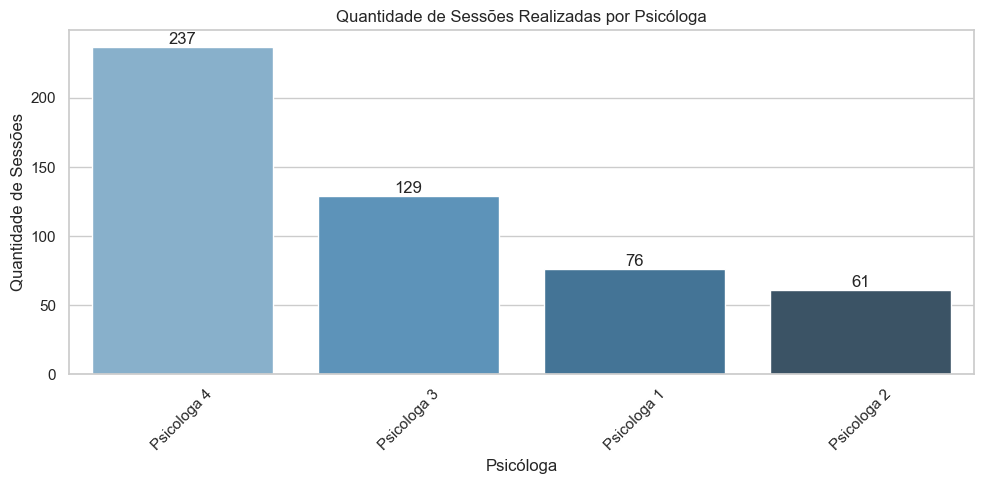

In [24]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=atend_por_psicologa,
    x="psicologa",
    y="qtd_sessoes",
    palette="Blues_d"
)

plt.title("Quantidade de Sessões Realizadas por Psicóloga")
plt.xlabel("Psicóloga")
plt.ylabel("Quantidade de Sessões")
plt.xticks(rotation=45)

# adiciona os valores nas barras
for container in ax.containers:
    ax.bar_label(container, label_type='edge')  # ou 'center'

plt.tight_layout()
plt.show()

In [25]:
receita_por_psicologa = (
    df_atendimentos[df_atendimentos["status"]=="realizada"]
    .groupby("psicologa", as_index=False)["valor_sessao"]
    .sum()
    .sort_values("valor_sessao", ascending=False)
)

receita_por_psicologa.rename(columns={"valor_sessao": "receita_total"}, inplace=True)
display(receita_por_psicologa)

,psicologa,receita_total
3,Psicologa 4,"32,047.00"
2,Psicologa 3,"15,975.00"
0,Psicologa 1,"8,776.50"
1,Psicologa 2,"6,470.00"


C:\Users\maria\AppData\Local\Temp\ipykernel_15000\643913700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


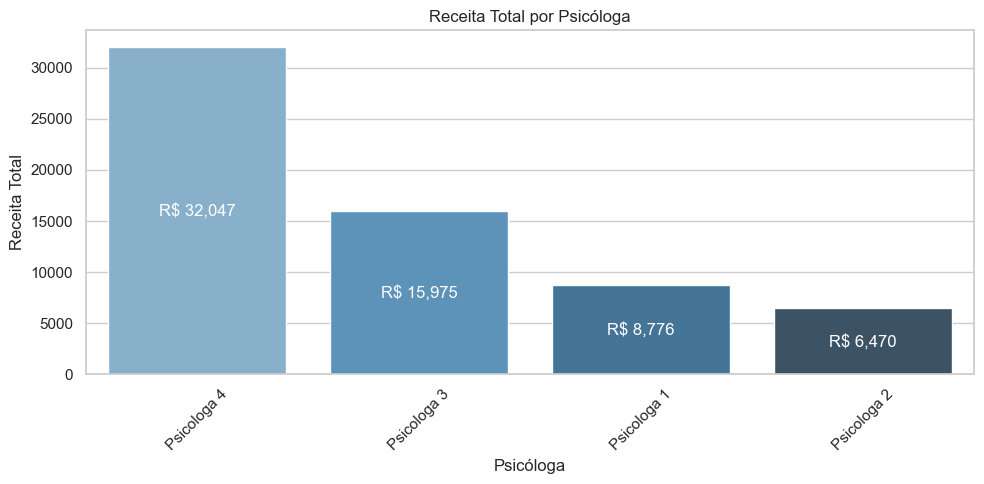

In [26]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=receita_por_psicologa,
    x="psicologa",
    y="receita_total",
    palette="Blues_d"
)

plt.title("Receita Total por Psicóloga")
plt.xlabel("Psicóloga")
plt.ylabel("Receita Total")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'R$ {v:,.0f}' for v in container.datavalues],
        label_type='center',
        color='white'
    )

plt.tight_layout()
plt.show()

## Perfil do Paciente

### Analise de Paciente por Idade

In [27]:
df_pacientes["idade"].value_counts(bins=5).reset_index()

,index,count
0,"(22.2, 35.4]",30
1,"(8.933, 22.2]",22
2,"(35.4, 48.6]",13
3,"(48.6, 61.8]",4
4,"(61.8, 75.0]",2


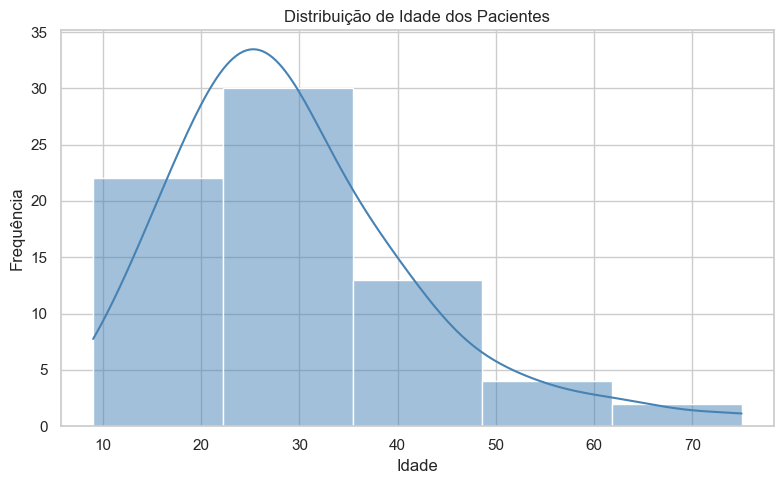

In [28]:
if "idade" in df_pacientes.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_pacientes["idade"].dropna(), bins=5, kde=True, color="steelblue")
    plt.title("Distribuição de Idade dos Pacientes")
    plt.xlabel("Idade")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

### Analise de Paciente por Gênero

In [29]:
genero_dist = df_pacientes["gênero"].value_counts().reset_index()
genero_dist.columns = ["gênero", "quantidade"]

display(genero_dist)

,gênero,quantidade
0,Feminino,60
1,Masculino,15
2,Não - Binárie,1


In [30]:
genero_counts = df_pacientes["gênero"].value_counts()
genero_pct = (genero_counts / genero_counts.sum()) * 100

df_genero = pd.DataFrame({
    "genero": genero_counts.index,
    "quantidade": genero_counts.values,
    "percentual": genero_pct.values
})

C:\Users\maria\AppData\Local\Temp\ipykernel_15000\3681024952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


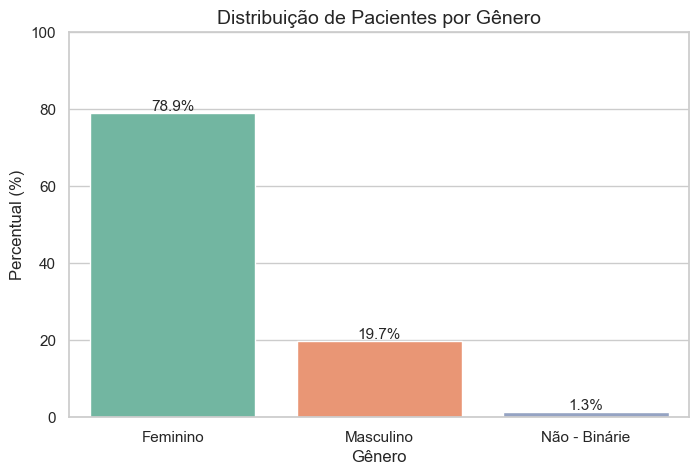

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_genero,
    x="genero",
    y="percentual",
    palette="Set2"
)

# adicionar porcentagem em cima das barras
for i, row in df_genero.iterrows():
    plt.text(
        i,
        row["percentual"] + 0.5,
        f"{row['percentual']:.1f}%",
        ha='center',
        fontsize=11
    )

plt.title("Distribuição de Pacientes por Gênero", fontsize=14)
plt.xlabel("Gênero")
plt.ylabel("Percentual (%)")

plt.ylim(0, 100)

plt.show()

## Analise de Origem dos Pacientes

In [32]:
origem_dist = df_pacientes["como_conheceu_a_clínica"].value_counts().reset_index()
origem_dist.columns = ["como_conheceu_a_clínica", "quantidade"]

display(origem_dist)

,como_conheceu_a_clínica,quantidade
0,Indicação Psicólogo,19
1,Google,14
2,Central de Terapia,13
3,Indicação Paciente Horizonte,11
4,Instagram,6
5,BNI,5
6,Outras Indicações,4
7,Indicação Médico,3
8,Anúncio Prédio,1


In [33]:
origem_counts = df_pacientes["como_conheceu_a_clínica"].value_counts()
origem_pct = (origem_counts / origem_counts.sum()) * 100

df_origem = pd.DataFrame({
    "origem": origem_counts.index,
    "quantidade": origem_counts.values,
    "percentual": origem_pct.values
})

C:\Users\maria\AppData\Local\Temp\ipykernel_15000\1684227286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


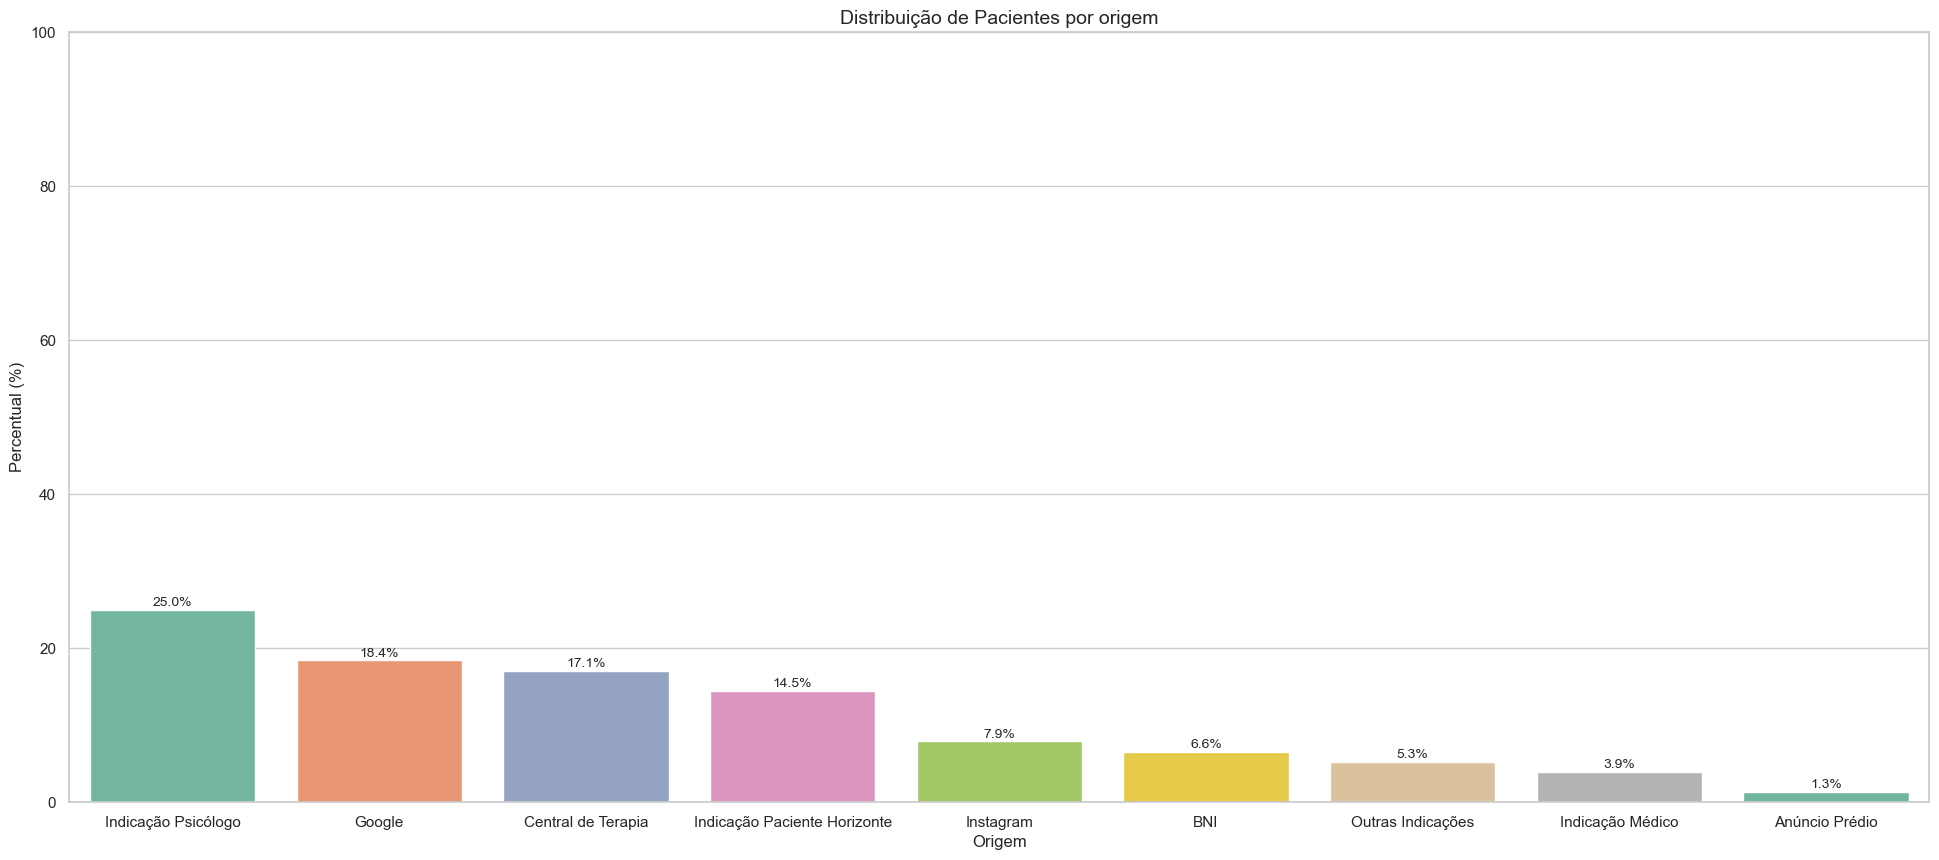

In [34]:
plt.figure(figsize=(24,10))

sns.barplot(
    data=df_origem,
    x="origem",
    y="percentual",
    palette="Set2"
)

# adicionar porcentagem em cima das barras
for i, row in df_origem.iterrows():
    plt.text(
        i,
        row["percentual"] + 0.5,
        f"{row['percentual']:.1f}%",
        ha='center',
        fontsize=10
    )

plt.title("Distribuição de Pacientes por origem", fontsize=14)
plt.xlabel("Origem")
plt.ylabel("Percentual (%)")

plt.ylim(0, 100)

plt.show()

## Simulação de Impacto Financeiro

### Simulação de Cenários: Avaliação do Lucro Líquido após aumento de R$ 3,00 no custo unitário por psicóloga.

In [35]:
psicologas_alvo = ["Psicologa 1","Psicologa 2","Psicologa 3"]

In [36]:
resultado_mensal = pd.merge(
    receita_mensal,
    gastos_mensais,
    on="mes",
    how="left"
)

resultado_mensal["gasto_mensal"] = resultado_mensal["gasto_mensal"].fillna(0)
resultado_mensal["lucro_estimado"] = resultado_mensal["receita_mensal"] - resultado_mensal["gasto_mensal"]

display(resultado_mensal)

,mes,receita_mensal,gasto_mensal,lucro_estimado
0,Dezembro,"19,171.00","12,434.44","6,736.56"
1,Fevereiro,"22,250.00","11,862.66","10,387.34"
2,Janeiro,"21,847.50","11,685.88","10,161.62"


In [37]:
df_alvo = df_atendimentos[
    (df_atendimentos["status"] == "realizada") &
    (df_atendimentos["psicologa"].isin(psicologas_alvo))
].copy()

display(df_alvo.head())

,data,nome,psicologa,tipo_atendimento,valor_sessao,status,motivo,obs,mes
0,2025-12-02,Paciente 26,Psicologa 1,Individual,100.00,realizada,-,-,Dezembro
1,2025-12-02,Paciente 34,Psicologa 1,Individual,100.00,realizada,-,-,Dezembro
2,2025-12-02,Paciente 32,Psicologa 1,Individual,60.00,realizada,-,-,Dezembro
3,2025-12-02,Paciente 30,Psicologa 1,Individual,150.00,realizada,-,-,Dezembro
4,2025-12-02,Paciente 27,Psicologa 1,Individual,150.00,realizada,-,-,Dezembro


In [38]:
aumento_por_sessao = 3.0

impacto_mensal = (
    df_alvo[df_alvo["tipo_atendimento"] != "Atendimento Social"]
    .groupby("mes", as_index=False)
    .size()
    .rename(columns={"size": "qtd_sessoes_alvo"})
)

impacto_mensal["impacto_adicional"] = (
    impacto_mensal["qtd_sessoes_alvo"] * aumento_por_sessao
)

display(impacto_mensal)

,mes,qtd_sessoes_alvo,impacto_adicional
0,Dezembro,70,210.00
1,Fevereiro,83,249.00
2,Janeiro,77,231.00


In [39]:

resultado_simulado = pd.merge(
    resultado_mensal,
    impacto_mensal[["mes", "impacto_adicional"]],
    on="mes",
    how="left"
)

resultado_simulado["impacto_adicional"] = resultado_simulado["impacto_adicional"].fillna(0)
resultado_simulado["novo_lucro_estimado"] = resultado_simulado["lucro_estimado"] - resultado_simulado["impacto_adicional"]
resultado_simulado["variacao_percentual_lucro"] = np.where(
    resultado_simulado["lucro_estimado"] != 0,
    ((resultado_simulado["novo_lucro_estimado"] - resultado_simulado["lucro_estimado"]) / resultado_simulado["lucro_estimado"]) * 100,
    np.nan
)

display(resultado_simulado)

,mes,receita_mensal,gasto_mensal,lucro_estimado,impacto_adicional,novo_lucro_estimado,variacao_percentual_lucro
0,Dezembro,"19,171.00","12,434.44","6,736.56",210.00,"6,526.56",-3.12
1,Fevereiro,"22,250.00","11,862.66","10,387.34",249.00,"10,138.34",-2.40
2,Janeiro,"21,847.50","11,685.88","10,161.62",231.00,"9,930.62",-2.27


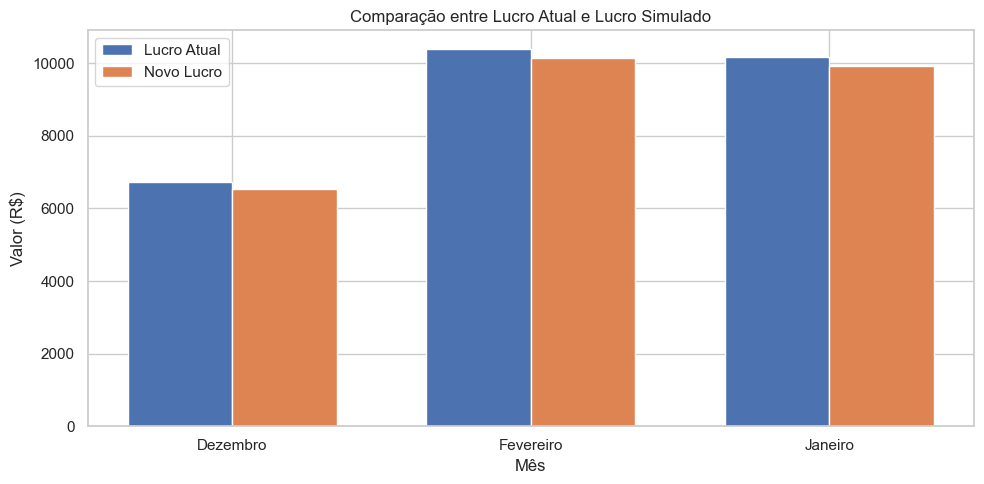

In [40]:
plt.figure(figsize=(10, 5))

x = np.arange(len(resultado_simulado))
width = 0.35

plt.bar(x - width/2, resultado_simulado["lucro_estimado"], width=width, label="Lucro Atual")
plt.bar(x + width/2, resultado_simulado["novo_lucro_estimado"], width=width, label="Novo Lucro")

plt.xticks(x, resultado_simulado["mes"])
plt.title("Comparação entre Lucro Atual e Lucro Simulado")
plt.xlabel("Mês")
plt.ylabel("Valor (R$)")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
impacto_por_psicologa = (
    df_alvo.groupby("psicologa")
    .size()
    .reset_index(name="qtd_sessoes")
)

impacto_por_psicologa["impacto_adicional"] = impacto_por_psicologa["qtd_sessoes"] * aumento_por_sessao
impacto_por_psicologa = impacto_por_psicologa.sort_values("impacto_adicional", ascending=False)

display(impacto_por_psicologa)

,psicologa,qtd_sessoes,impacto_adicional
2,Psicologa 3,129,387.00
0,Psicologa 1,76,228.00
1,Psicologa 2,61,183.00


In [42]:
impacto_total = resultado_simulado["impacto_adicional"].sum()
lucro_total_atual = resultado_simulado["lucro_estimado"].sum()
novo_lucro_total = resultado_simulado["novo_lucro_estimado"].sum()

print(f"Lucro total atual no período: R$ {lucro_total_atual:,.2f}")
print(f"Impacto adicional total com reajuste: R$ {impacto_total:,.2f}")
print(f"Novo lucro total estimado: R$ {novo_lucro_total:,.2f}")

Lucro total atual no período: R$ 27,285.52
Impacto adicional total com reajuste: R$ 690.00
Novo lucro total estimado: R$ 26,595.52


In [43]:
print("==== CONCLUSÕES DO PROJETO ====")
print(f"1. O impacto adicional total estimado no período foi de R$ {impacto_total:,.2f}.")
print(f"2. O lucro total atual estimado foi de R$ {lucro_total_atual:,.2f}.")
print(f"3. Com o reajuste, o novo lucro total estimado seria de R$ {novo_lucro_total:,.2f}.")
print("4. A análise considera apenas sessões válidas das 3 psicólogas selecionadas.")
print("5. Recomenda-se avaliar também o impacto de cancelamentos e faltas, pois reduzir perdas pode gerar ganho financeiro adicional.")

==== CONCLUSÕES DO PROJETO ====
1. O impacto adicional total estimado no período foi de R$ 690.00.
2. O lucro total atual estimado foi de R$ 27,285.52.
3. Com o reajuste, o novo lucro total estimado seria de R$ 26,595.52.
4. A análise considera apenas sessões válidas das 3 psicólogas selecionadas.
5. Recomenda-se avaliar também o impacto de cancelamentos e faltas, pois reduzir perdas pode gerar ganho financeiro adicional.
